ABM – Excitable Media (Christensen et al. 2015)

[1/3] Regime C – Healthy tissue (ν = 0.9)


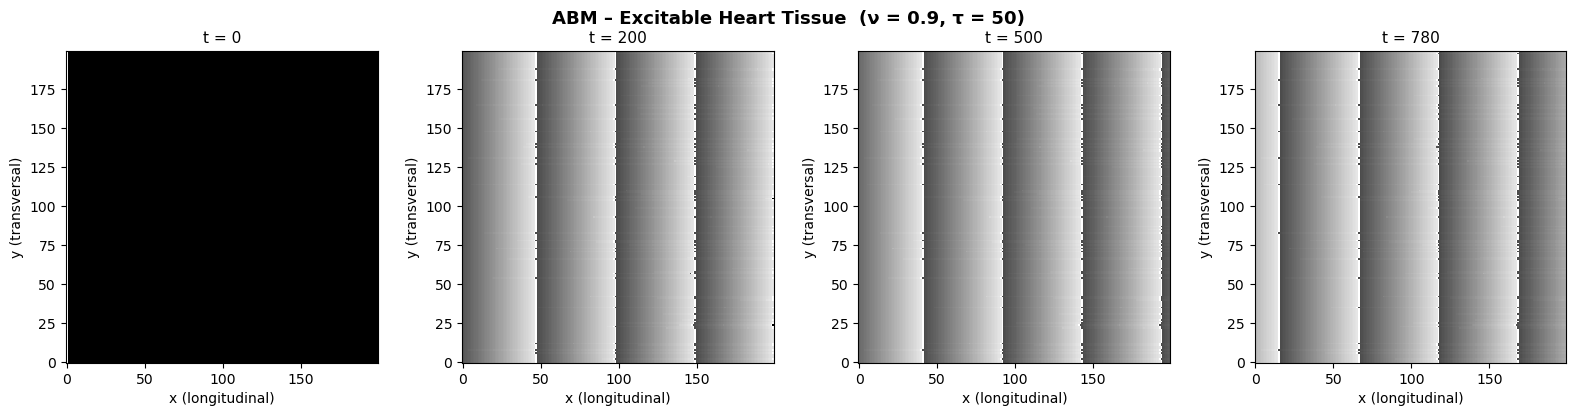


[2/3] Regime B – Intermediate (ν = 0.20)


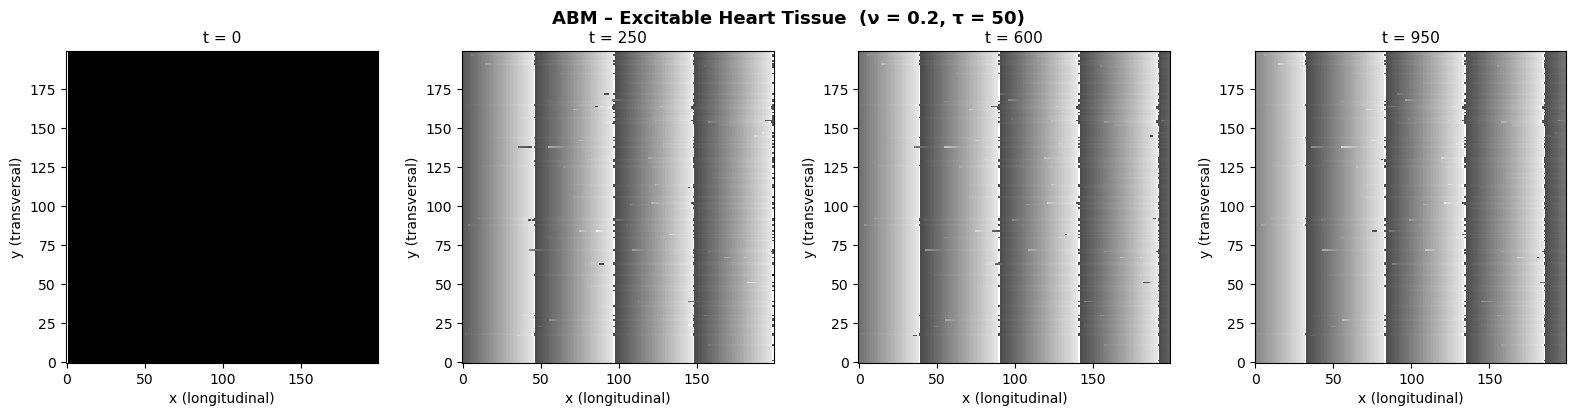


[3/3] Regime A – AF (ν = 0.10)


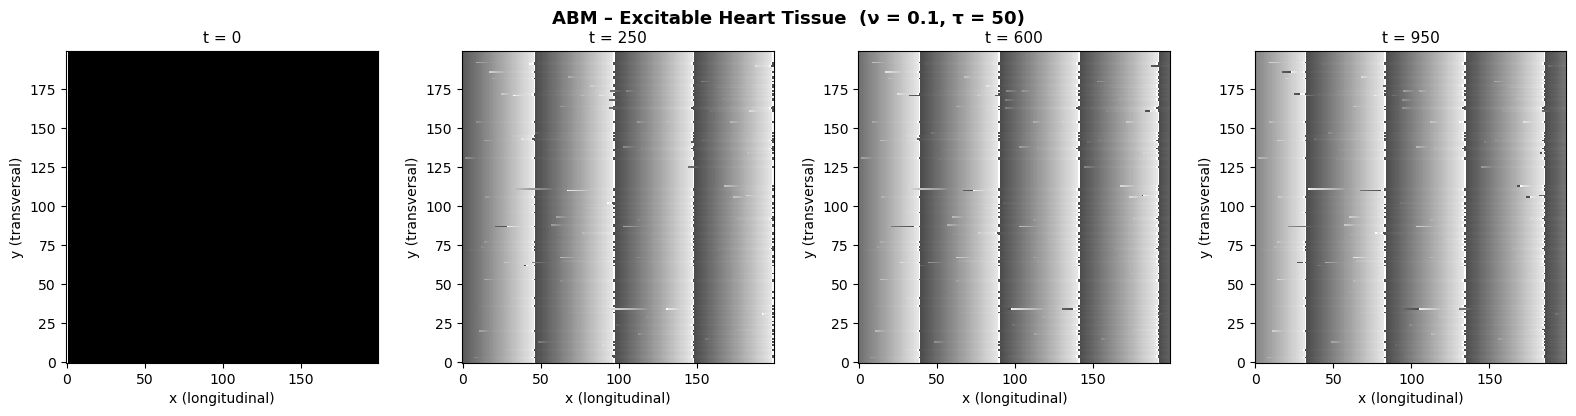


[4/4] Analytical risk curve


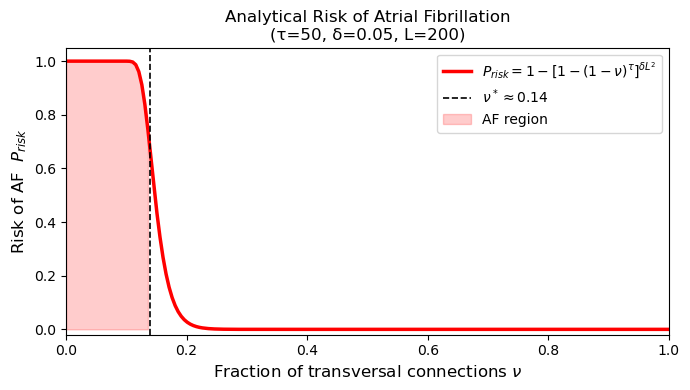

In [12]:
"""
Agent-Based Model of Excitable Media (Heart Arrhythmia)
Based on: Christensen et al., PRL 114, 028104 (2015)
         & Week 4 lecture notes (Physics of Molecular Diseases by Prof. Ala Trusina)

Model summary:
- 2D grid L x L of cardiomyocytes
- Each cell: Resting → (if excited) → Excited → Refractory(τ steps) → Resting
- Longitudinal coupling: always present
- Transversal coupling: with probability ν (ν=1: young/healthy, ν<1: aged/fibrotic)
- Dysfunctional cells: fraction δ, fail to excite with probability ε
- Pacemaker: left column, fires every T steps
- Boundary conditions: periodic (vertical), open (horizontal)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap

# ──────────────────────────────────────────────
# 1. PARAMETERS  (Table from Christensen 2015)
# ──────────────────────────────────────────────
L     = 200      # grid size (after coarse-graining b=5 from L'=1000)
TAU   = 50       # refractory period (τ' / (b·Δt') = 150ms / 3ms = 50 steps)
T     = 220      # pacemaker period  (T' / (b·Δt') = 660ms / 3ms = 220 steps)
NU    = 0.15     # fraction of transversal connections (ν < ν* ≈ 0.14 → AF)
DELTA = 0.05     # fraction of dysfunctional cells
EPS   = 0.05     # probability a dysfunctional cell fails to fire

# Cell states
RESTING    = 0
EXCITED    = 1
# Refractory states: integers 2 … TAU+1  (TAU+1 = most recently entered refractory)

RNG = np.random.default_rng(seed=42)


# ──────────────────────────────────────────────
# 2. BUILD THE SUBSTRATE
# ──────────────────────────────────────────────
def build_substrate(L, nu, delta, eps, rng):
    """
    Returns:
      transv_up[i,j]  : bool – cell (i,j) connected to (i-1,j)  [upward transversal]
      transv_dn[i,j]  : bool – cell (i,j) connected to (i+1,j)  [downward transversal]
      dysfunc[i,j]    : bool – cell is dysfunctional
    """
    # Transversal connections: each pair of vertical neighbours shares a link
    # A link exists with probability ν.  We store it on the upper cell.
    transv = rng.random((L, L)) < nu          # (i,j) has upward link to (i-1,j)
    # periodic BC vertically: wrap around
    transv_up = transv                        # (i,j) ↔ (i-1 mod L, j)
    transv_dn = np.roll(transv, -1, axis=0)  # (i,j) ↔ (i+1 mod L, j)

    dysfunc = rng.random((L, L)) < delta

    return transv_up, transv_dn, dysfunc


# ──────────────────────────────────────────────
# 3. ONE TIME-STEP UPDATE
# ──────────────────────────────────────────────
def step(state, transv_up, transv_dn, dysfunc, pacemaker_fire, rng, eps=EPS):
    """
    state: 2D array, shape (L, L)
           0         = Resting
           1         = Excited (just fired this step)
           2..TAU+1  = Refractory (countdown; TAU+1 = just became refractory)
    Returns new_state (same shape).
    """
    new_state = np.zeros_like(state)

    # ── Refractory cells: decrement counter ──
    refr_mask = state >= 2
    new_state[refr_mask] = state[refr_mask] - 1   # counts down to 1, then → 0 (Resting)

    # ── Excited cells → Refractory ──
    excit_mask = state == 1
    new_state[excit_mask] = TAU + 1                # enter refractory

    # ── Resting cells: can become excited ──
    resting_mask = state == 0

    # Which neighbours are excited?
    excit = (state == 1)

    # Longitudinal neighbours (left/right) – always coupled
    excit_left  = np.roll(excit,  1, axis=1)   # neighbour to the left
    excit_right = np.roll(excit, -1, axis=1)   # neighbour to the right
    # Open BC: no wrapping at the horizontal boundaries
    excit_left[:, 0]  = False
    excit_right[:, -1] = False

    # Transversal neighbours (up/down) – coupled with probability ν
    excit_up = np.roll(excit,  1, axis=0) & transv_up   # excited cell above + link exists
    excit_dn = np.roll(excit, -1, axis=0) & transv_dn   # excited cell below + link exists

    has_excited_neighbour = excit_left | excit_right | excit_up | excit_dn

    # Pacemaker: left column fires every T steps
    if pacemaker_fire:
        has_excited_neighbour[:, 0] = True

    # Cells that would be excited
    candidates = resting_mask & has_excited_neighbour

    # Dysfunctional cells fail with probability ε
    fail = rng.random((state.shape[0], state.shape[1])) < eps
    actually_fire = candidates & ~(dysfunc & fail)

    new_state[actually_fire] = 1  # set to Excited

    return new_state


# ──────────────────────────────────────────────
# 4. RUN SIMULATION
# ──────────────────────────────────────────────
def run_simulation(L=L, nu=NU, delta=DELTA, eps=EPS, tau=TAU, T_pace=T,
                   n_steps=1200, rng=RNG, snapshot_times=None):
    """
    Runs the ABM and returns:
      snapshots : list of (time, state_array) for requested snapshot_times
      pwave_frac: list of fraction of non-planar cells at each step (for phase diagram)
    """
    transv_up, transv_dn, dysfunc = build_substrate(L, nu, delta, eps, rng)

    state = np.zeros((L, L), dtype=np.int32)   # all Resting
    t_since_pace = 0

    if snapshot_times is None:
        snapshot_times = set()
    else:
        snapshot_times = set(snapshot_times)

    snapshots  = []
    nonplanar_frac = []

    for t in range(n_steps):
        pacemaker_fire = (t_since_pace == 0)
        state = step(state, transv_up, transv_dn, dysfunc, pacemaker_fire, rng, eps)

        t_since_pace += 1
        if t_since_pace >= T_pace:
            t_since_pace = 0

        if t in snapshot_times:
            snapshots.append((t, state.copy()))

        # Measure "non-planarity": fraction of cells NOT in the rightward-sweeping front
        # Simple proxy: std of excited cell columns (high = many wave fronts)
        excited_cols = np.where(state == 1)[1] if np.any(state == 1) else np.array([])
        nonplanar_frac.append(np.std(excited_cols) if len(excited_cols) > 0 else 0.0)

    return snapshots, nonplanar_frac


# ──────────────────────────────────────────────
# 5.  VISUALISATION HELPERS
# ──────────────────────────────────────────────
def state_to_image(state):
    """Convert state array to greyscale image: Resting=0, Excited=1, Refractory=0.3-0.9"""
    img = np.zeros_like(state, dtype=float)
    img[state == 1] = 1.0                                      # Excited → white
    refr = state >= 2
    img[refr] = 0.3 + 0.6 * (state[refr] - 2) / (TAU - 1)    # Refractory → grey gradient
    return img


def plot_snapshots(snapshots, nu, save_path=None):
    n = len(snapshots)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (t, st) in zip(axes, snapshots):
        ax.imshow(state_to_image(st), cmap='gray', vmin=0, vmax=1,
                  origin='lower', interpolation='nearest')
        ax.set_title(f't = {t}', fontsize=11)
        ax.set_xlabel('x (longitudinal)')
        ax.set_ylabel('y (transversal)')
    fig.suptitle(f'ABM – Excitable Heart Tissue  (ν = {nu}, τ = {TAU})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


# ──────────────────────────────────────────────
# 6. RISK CURVE  (analytical + numerical)
# ──────────────────────────────────────────────
def analytical_risk(nu_vals, tau=TAU, delta=DELTA, L=L):
    """
    P_risk = 1 − [1 − (1−ν)^τ]^(δL²)
    Equation (2) of Christensen et al. 2015
    """
    return 1 - (1 - (1 - nu_vals) ** tau) ** (delta * L ** 2)


def estimate_numerical_risk(nu_list, n_trials=10, n_steps=1500, **kwargs):
    """
    For each ν, run n_trials simulations and record fraction that develop spirals.
    "Spiral" proxy: mean(nonplanar_frac) in last half of simulation > threshold.
    """
    risks = []
    for nu in nu_list:
        spiral_count = 0
        for _ in range(n_trials):
            rng_trial = np.random.default_rng()
            _, npf = run_simulation(nu=nu, n_steps=n_steps, rng=rng_trial,
                                    snapshot_times=set(), **kwargs)
            # Proxy: large std of excited columns → multiple wave fronts
            mean_nonplanar = np.mean(npf[n_steps // 2:])
            if mean_nonplanar > 20:   # threshold (heuristic)
                spiral_count += 1
        risks.append(spiral_count / n_trials)
        print(f"  ν = {nu:.2f}  →  P_risk_numerical ≈ {risks[-1]:.2f}")
    return risks


def plot_risk_curve(save_path=None):
    nu_vals = np.linspace(0.0, 1.0, 200)
    p_analytical = analytical_risk(nu_vals)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(nu_vals, p_analytical, 'r-', lw=2.5,
            label=r'$P_{risk} = 1 - [1-(1-\nu)^\tau]^{\delta L^2}$')
    ax.axvline(x=0.14, color='k', ls='--', lw=1.2, label=r'$\nu^* \approx 0.14$')
    ax.fill_between(nu_vals[nu_vals < 0.14], p_analytical[nu_vals < 0.14],
                    alpha=0.2, color='red', label='AF region')
    ax.set_xlabel(r'Fraction of transversal connections $\nu$', fontsize=12)
    ax.set_ylabel(r'Risk of AF  $P_{risk}$', fontsize=12)
    ax.set_title('Analytical Risk of Atrial Fibrillation\n'
                 f'(τ={TAU}, δ={DELTA}, L={L})', fontsize=12)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.05)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


# ──────────────────────────────────────────────
# 7. MAIN: run three regimes
# ──────────────────────────────────────────────
if __name__ == "__main__":

    print("=" * 60)
    print("ABM – Excitable Media (Christensen et al. 2015)")
    print("=" * 60)

    # ── Regime C: ν = 0.9  (healthy, planar waves) ──────────────
    print("\n[1/3] Regime C – Healthy tissue (ν = 0.9)")
    snaps_C, _ = run_simulation(nu=0.9, n_steps=800,
                                snapshot_times={0, 200, 500, 780},
                                rng=np.random.default_rng(1))
    plot_snapshots(snaps_C, nu=0.9, save_path=None)

    # ── Regime B: ν = 0.20  (occasional self-terminating spirals) ──
    print("\n[2/3] Regime B – Intermediate (ν = 0.20)")
    snaps_B, _ = run_simulation(nu=0.20, n_steps=1000,
                                snapshot_times={0, 250, 600, 950},
                                rng=np.random.default_rng(2))
    plot_snapshots(snaps_B, nu=0.20, save_path=None)

    # ── Regime A: ν = 0.10  (persistent AF, multiple spirals) ───
    print("\n[3/3] Regime A – AF (ν = 0.10)")
    snaps_A, _ = run_simulation(nu=0.10, n_steps=1000,
                                snapshot_times={0, 250, 600, 950},
                                rng=np.random.default_rng(3))
    plot_snapshots(snaps_A, nu=0.10, save_path=None)

    # ── Analytical risk curve ─────────────────────────────────────
    print("\n[4/4] Analytical risk curve")
    plot_risk_curve(save_path=None)


=== EXPERIMENT A: Noise in Refractory Period (ν=1) ===
  σ_τ = 0 ...
  σ_τ = 5 ...
  σ_τ = 15 ...
  σ_τ = 25 ...


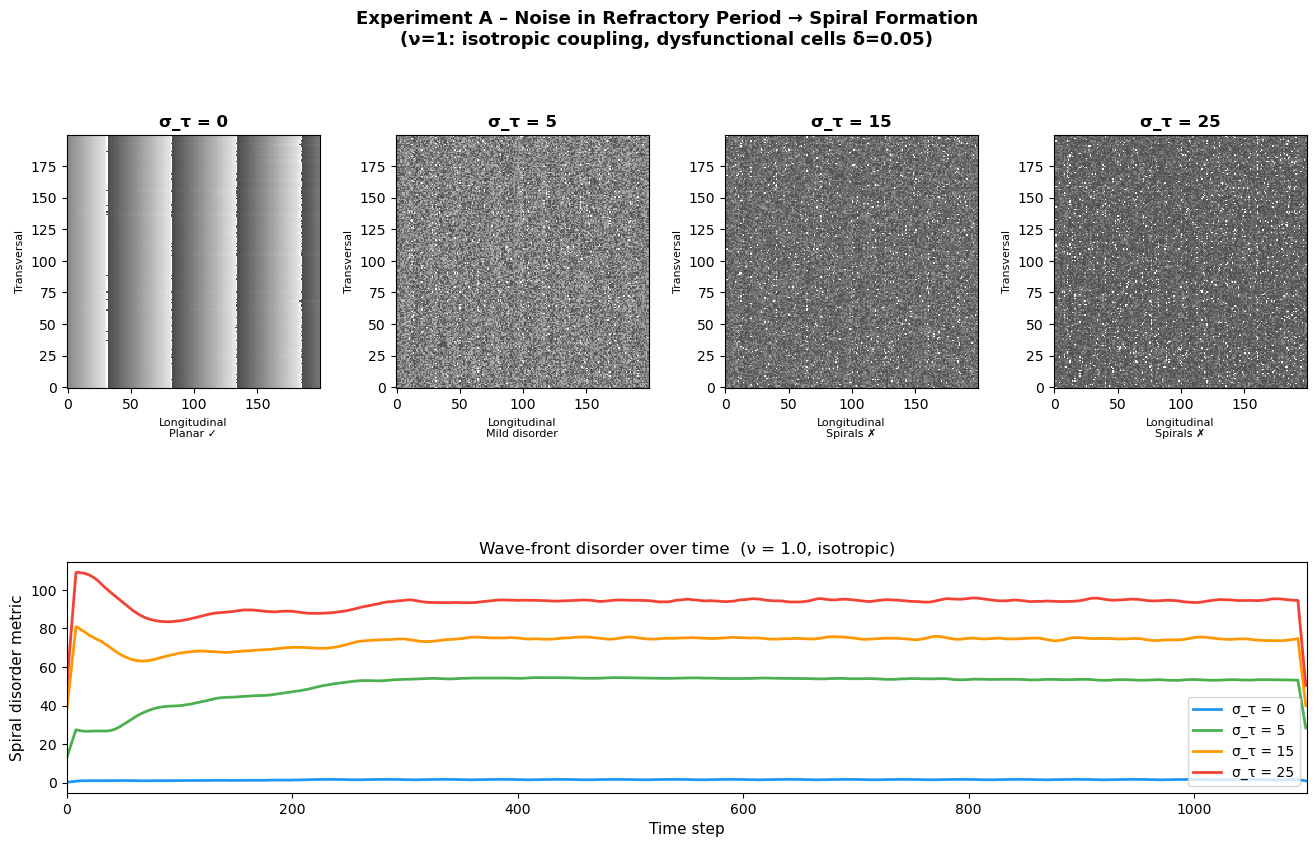


=== EXPERIMENT B: Isotropic vs Anisotropic Coupling (σ_τ=10) ===
  ν = 0.1 ...
  ν = 0.2 ...
  ν = 0.5 ...
  ν = 1.0 ...


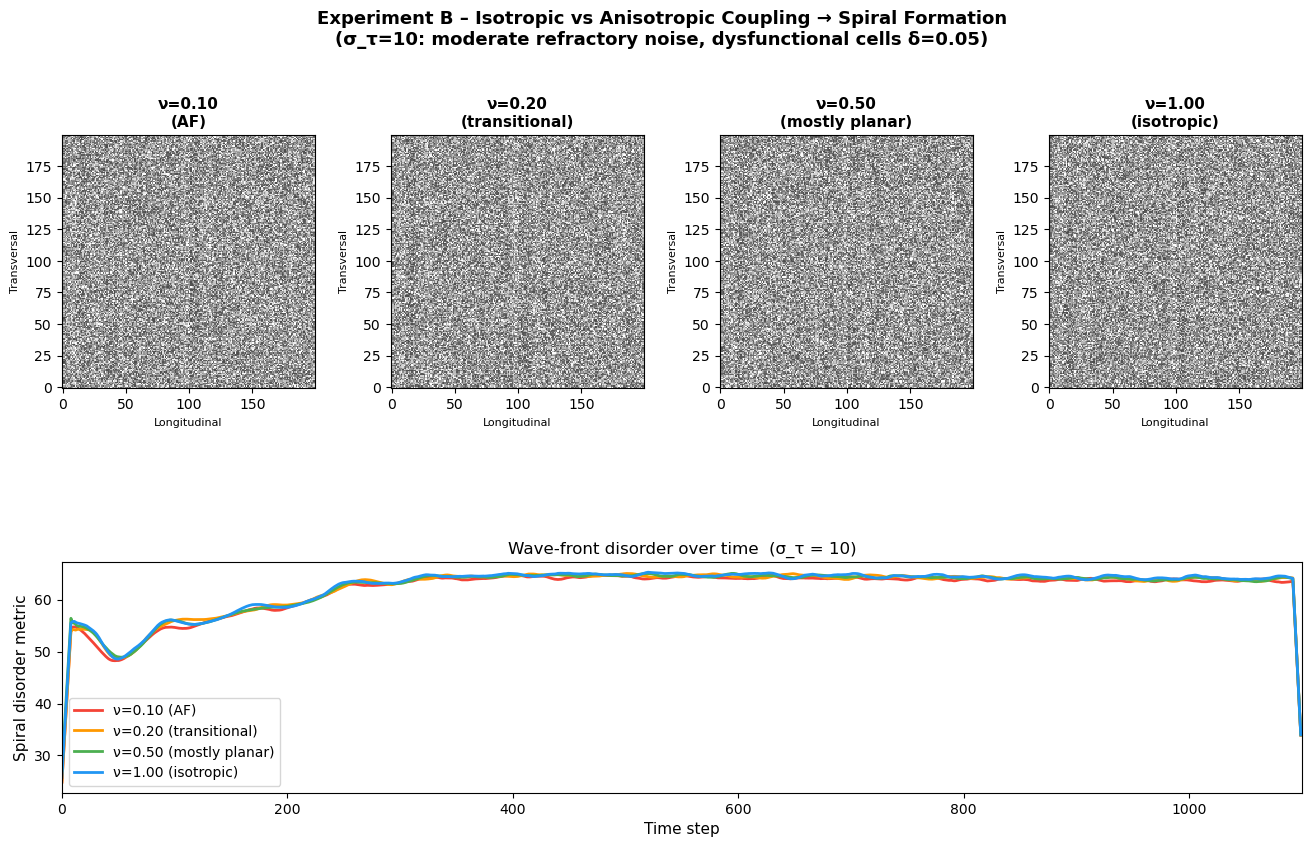


=== EXPERIMENT C: 2D Phase Diagram (ν vs σ_τ) ===
  ν=0.05  σ_τ= 0  →  disorder=27.6
  ν=0.10  σ_τ= 0  →  disorder=17.0
  ν=0.15  σ_τ= 0  →  disorder=11.1
  ν=0.20  σ_τ= 0  →  disorder=8.3
  ν=0.35  σ_τ= 0  →  disorder=3.4
  ν=0.60  σ_τ= 0  →  disorder=1.9
  ν=1.00  σ_τ= 0  →  disorder=2.4
  ν=0.05  σ_τ= 5  →  disorder=54.0
  ν=0.10  σ_τ= 5  →  disorder=54.1
  ν=0.15  σ_τ= 5  →  disorder=54.1
  ν=0.20  σ_τ= 5  →  disorder=53.9
  ν=0.35  σ_τ= 5  →  disorder=53.9
  ν=0.60  σ_τ= 5  →  disorder=54.0
  ν=1.00  σ_τ= 5  →  disorder=54.0
  ν=0.05  σ_τ=10  →  disorder=64.5
  ν=0.10  σ_τ=10  →  disorder=64.4
  ν=0.15  σ_τ=10  →  disorder=64.6
  ν=0.20  σ_τ=10  →  disorder=64.3
  ν=0.35  σ_τ=10  →  disorder=64.7
  ν=0.60  σ_τ=10  →  disorder=64.4
  ν=1.00  σ_τ=10  →  disorder=64.5
  ν=0.05  σ_τ=15  →  disorder=74.0
  ν=0.10  σ_τ=15  →  disorder=74.1
  ν=0.15  σ_τ=15  →  disorder=74.5
  ν=0.20  σ_τ=15  →  disorder=74.7
  ν=0.35  σ_τ=15  →  disorder=74.6
  ν=0.60  σ_τ=15  →  disorder=74.3
  ν=1.00

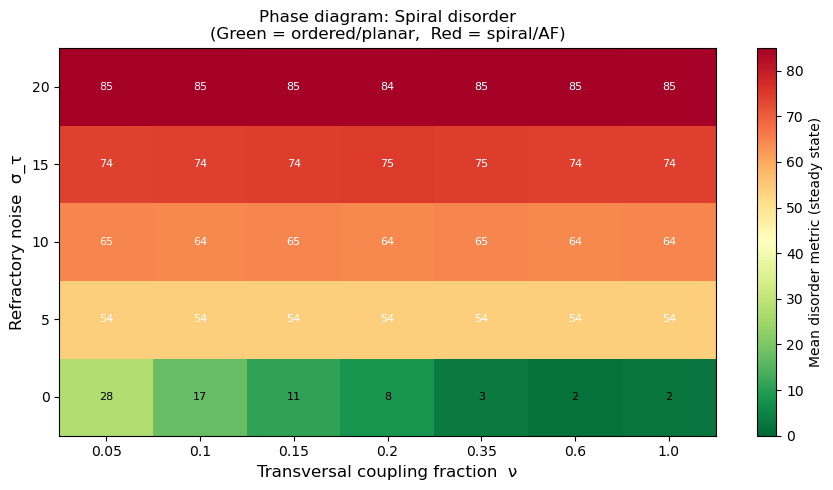

In [14]:
"""
Spiral Formation in Excitable Media
=====================================
Investigates TWO mechanisms:
  a) Noise in the refractory period  (ν=1 isotropic, varying σ_τ)
  b) Isotropic coupling               (σ_τ fixed, varying ν)

Spiral detector: fraction of cells in refractory state that are
NOT adjacent to an excited cell (= "orphaned refractory" cells
created by wave-break / reentry).  High → spiral activity.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Parameters ──────────────────────────────
L      = 200
TAU    = 50
T_PACE = 220
DELTA  = 0.05
EPS    = 0.05


# ── Substrate ────────────────────────────────
def build_substrate(L, nu, delta, rng):
    transv    = rng.random((L, L)) < nu
    transv_up = transv
    transv_dn = np.roll(transv, -1, axis=0)
    dysfunc   = rng.random((L, L)) < delta
    return transv_up, transv_dn, dysfunc


# ── Per-cell τ grid ───────────────────────────
def make_tau_grid(L, tau_mean, sigma, rng):
    if sigma == 0:
        return np.full((L, L), tau_mean, dtype=int)
    tau_g = np.round(tau_mean + rng.normal(0, sigma, (L, L))).astype(int)
    return np.clip(tau_g, 5, 3 * tau_mean)


# ── One step ─────────────────────────────────
def step(state, transv_up, transv_dn, dysfunc, tau_grid,
         pacemaker_fire, rng, eps=EPS):
    new_state = np.zeros_like(state)

    refr_mask = state >= 2
    new_state[refr_mask] = state[refr_mask] - 1

    excit_mask = state == 1
    new_state[excit_mask] = tau_grid[excit_mask] + 1

    resting_mask = state == 0
    excit = state == 1

    excit_left  = np.roll(excit,  1, axis=1); excit_left[:, 0]   = False
    excit_right = np.roll(excit, -1, axis=1); excit_right[:, -1] = False
    excit_up = np.roll(excit,  1, axis=0) & transv_up
    excit_dn = np.roll(excit, -1, axis=0) & transv_dn

    has_excit_nbr = excit_left | excit_right | excit_up | excit_dn
    if pacemaker_fire:
        has_excit_nbr[:, 0] = True

    candidates    = resting_mask & has_excit_nbr
    fail          = rng.random((L, L)) < eps
    actually_fire = candidates & ~(dysfunc & fail)
    new_state[actually_fire] = 1
    return new_state


# ── Spiral metric ─────────────────────────────
def spiral_metric(state):
    """
    Counts refractory cells that are NOT part of a clean planar front.
    Proxy: number of refractory cells whose column position has HIGH
    variance across rows (wave-break indicator).

    Better metric: for each column, compute the RANGE of refractory
    levels present.  A planar front has one refractory level per column;
    spirals create multiple levels → high column-range.
    """
    n_excited = np.sum(state == 1)
    if n_excited == 0:
        return 0.0
    # For each column, how many distinct refractory "ages" are present?
    col_disorder = 0.0
    refr_rows, refr_cols = np.where(state >= 2)
    if len(refr_rows) == 0:
        return 0.0
    for c in np.unique(refr_cols):
        vals = state[state[:, c] >= 2, c]  # refractory values in this column
        if len(vals) > 1:
            col_disorder += (vals.max() - vals.min())
    # Normalise by number of columns that have any refractory cells
    n_refr_cols = len(np.unique(refr_cols))
    return col_disorder / max(n_refr_cols, 1)


# ── Simulation ────────────────────────────────
def run_sim(nu, sigma_tau, delta=DELTA, eps=EPS,
            n_steps=1200, snapshot_times=None, seed=42):
    rng = np.random.default_rng(seed)
    if snapshot_times is None:
        snapshot_times = set()

    transv_up, transv_dn, dysfunc = build_substrate(L, nu, delta, rng)
    tau_grid = make_tau_grid(L, TAU, sigma_tau, rng)

    state        = np.zeros((L, L), dtype=np.int32)
    t_since_pace = 0
    snapshots    = []
    metrics      = []

    for t in range(n_steps):
        pacemaker_fire = (t_since_pace == 0)
        state = step(state, transv_up, transv_dn, dysfunc,
                     tau_grid, pacemaker_fire, rng, eps)
        t_since_pace = (t_since_pace + 1) % T_PACE

        if t in snapshot_times:
            snapshots.append((t, state.copy()))

        metrics.append(spiral_metric(state))

    return snapshots, metrics, tau_grid


# ── Image helper ──────────────────────────────
def to_img(state, tau_max=TAU):
    img = np.zeros_like(state, dtype=float)
    img[state == 1] = 1.0
    refr = state >= 2
    if refr.any():
        img[refr] = 0.3 + 0.6 * (state[refr] - 2) / max(tau_max - 1, 1)
    return img


# ════════════════════════════════════════════════
# EXPERIMENT A  –  Noise in refractory period
# ════════════════════════════════════════════════
def experiment_A():
    print("\n=== EXPERIMENT A: Noise in Refractory Period (ν=1) ===")
    sigma_list = [0, 5, 15, 25]
    n_steps    = 1100
    snap_t     = 1000
    colors     = ['#2196F3','#4CAF50','#FF9800','#F44336']

    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 4, hspace=0.5, wspace=0.3,
                            height_ratios=[1.4, 1])

    all_metrics = []
    for col, sigma in enumerate(sigma_list):
        print(f"  σ_τ = {sigma} ...")
        snaps, met, tg = run_sim(nu=1.0, sigma_tau=sigma,
                                 n_steps=n_steps,
                                 snapshot_times={snap_t},
                                 seed=42+col)
        all_metrics.append(met)

        ax = fig.add_subplot(gs[0, col])
        if snaps:
            _, st = snaps[0]
            ax.imshow(to_img(st, int(tg.max())),
                      cmap='gray', vmin=0, vmax=1,
                      origin='lower', interpolation='nearest')
        ax.set_title(f'σ_τ = {sigma}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Longitudinal', fontsize=8)
        ax.set_ylabel('Transversal',  fontsize=8)

        # Arrow annotation
        status = 'Planar ✓' if sigma == 0 else ('Mild disorder' if sigma==5 else 'Spirals ✗')
        ax.set_xlabel(f'Longitudinal\n{status}', fontsize=8)

    ax_m = fig.add_subplot(gs[1, :])
    for sigma, met, color in zip(sigma_list, all_metrics, colors):
        # smooth
        window = 15
        smoothed = np.convolve(met, np.ones(window)/window, mode='same')
        ax_m.plot(smoothed, color=color, lw=2, label=f'σ_τ = {sigma}')
    ax_m.set_xlabel('Time step', fontsize=11)
    ax_m.set_ylabel('Spiral disorder metric', fontsize=11)
    ax_m.set_title('Wave-front disorder over time  (ν = 1.0, isotropic)',
                   fontsize=12)
    ax_m.legend(fontsize=10)
    ax_m.set_xlim(0, n_steps)

    fig.suptitle('Experiment A – Noise in Refractory Period → Spiral Formation\n'
                 '(ν=1: isotropic coupling, dysfunctional cells δ=0.05)',
                 fontsize=13, fontweight='bold')
    plt.show()


# ════════════════════════════════════════════════
# EXPERIMENT B  –  Isotropic vs anisotropic
# ════════════════════════════════════════════════
def experiment_B():
    print("\n=== EXPERIMENT B: Isotropic vs Anisotropic Coupling (σ_τ=10) ===")
    nu_list  = [0.10, 0.20, 0.50, 1.00]
    labels   = ['ν=0.10\n(AF)', 'ν=0.20\n(transitional)',
                'ν=0.50\n(mostly planar)', 'ν=1.00\n(isotropic)']
    colors   = ['#F44336','#FF9800','#4CAF50','#2196F3']
    n_steps  = 1100
    snap_t   = 1000

    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 4, hspace=0.5, wspace=0.3,
                            height_ratios=[1.4, 1])

    all_metrics = []
    for col, nu in enumerate(nu_list):
        print(f"  ν = {nu} ...")
        snaps, met, _ = run_sim(nu=nu, sigma_tau=10,
                                n_steps=n_steps,
                                snapshot_times={snap_t},
                                seed=99+col)
        all_metrics.append(met)

        ax = fig.add_subplot(gs[0, col])
        if snaps:
            _, st = snaps[0]
            ax.imshow(to_img(st), cmap='gray', vmin=0, vmax=1,
                      origin='lower', interpolation='nearest')
        ax.set_title(labels[col], fontsize=11, fontweight='bold')
        ax.set_xlabel('Longitudinal', fontsize=8)
        ax.set_ylabel('Transversal',  fontsize=8)

    ax_m = fig.add_subplot(gs[1, :])
    for nu, met, color, label in zip(nu_list, all_metrics, colors, labels):
        window = 15
        smoothed = np.convolve(met, np.ones(window)/window, mode='same')
        ax_m.plot(smoothed, color=color, lw=2,
                  label=label.replace('\n', ' '))
    ax_m.set_xlabel('Time step', fontsize=11)
    ax_m.set_ylabel('Spiral disorder metric', fontsize=11)
    ax_m.set_title('Wave-front disorder over time  (σ_τ = 10)',
                   fontsize=12)
    ax_m.legend(fontsize=10)
    ax_m.set_xlim(0, n_steps)

    fig.suptitle('Experiment B – Isotropic vs Anisotropic Coupling → Spiral Formation\n'
                 '(σ_τ=10: moderate refractory noise, dysfunctional cells δ=0.05)',
                 fontsize=13, fontweight='bold')
    plt.show()


# ════════════════════════════════════════════════
# EXPERIMENT C  –  2D phase diagram
# ════════════════════════════════════════════════
def experiment_C():
    print("\n=== EXPERIMENT C: 2D Phase Diagram (ν vs σ_τ) ===")
    nu_list    = [0.05, 0.10, 0.15, 0.20, 0.35, 0.60, 1.00]
    sigma_list = [0, 5, 10, 15, 20]
    n_steps    = 900

    mean_m = np.zeros((len(sigma_list), len(nu_list)))

    for i, sigma in enumerate(sigma_list):
        for j, nu in enumerate(nu_list):
            _, met, _ = run_sim(nu=nu, sigma_tau=sigma,
                                n_steps=n_steps, seed=i*20+j)
            mean_m[i, j] = np.mean(met[n_steps//2:])
            print(f"  ν={nu:.2f}  σ_τ={sigma:2d}  →  disorder={mean_m[i,j]:.1f}")

    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(mean_m, cmap='RdYlGn_r', aspect='auto',
                   origin='lower', vmin=0)
    ax.set_xticks(range(len(nu_list)))
    ax.set_xticklabels([str(n) for n in nu_list], fontsize=10)
    ax.set_yticks(range(len(sigma_list)))
    ax.set_yticklabels([str(s) for s in sigma_list], fontsize=10)
    ax.set_xlabel('Transversal coupling fraction  ν', fontsize=12)
    ax.set_ylabel('Refractory noise  σ_τ', fontsize=12)
    ax.set_title('Phase diagram: Spiral disorder\n'
                 '(Green = ordered/planar,  Red = spiral/AF)', fontsize=12)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean disorder metric (steady state)', fontsize=10)

    for i in range(len(sigma_list)):
        for j in range(len(nu_list)):
            ax.text(j, i, f'{mean_m[i,j]:.0f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if mean_m[i,j] > mean_m.max()*0.6 else 'black')

    plt.tight_layout()
    plt.show()


# ── MAIN ─────────────────────────────────────
if __name__ == "__main__":
    experiment_A()
    experiment_B()
    experiment_C()

Effect of Refractory Period τ on AF Risk

[1/3] Analytical curves ...


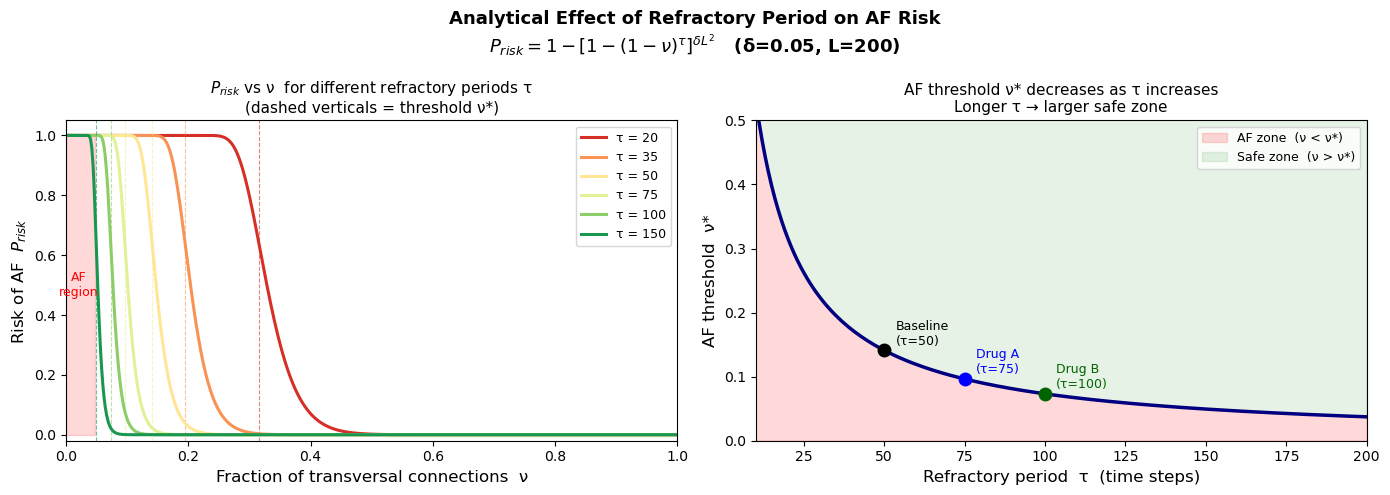


[2/3] ABM simulations (ν=0.15 fixed, varying τ) ...
  Simulating τ = 25 ...
  Simulating τ = 50 ...
  Simulating τ = 75 ...
  Simulating τ = 120 ...


/var/folders/7f/6htl829j2cgfgfgcl962_d4r0000gn/T/ipykernel_95857/2279582212.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


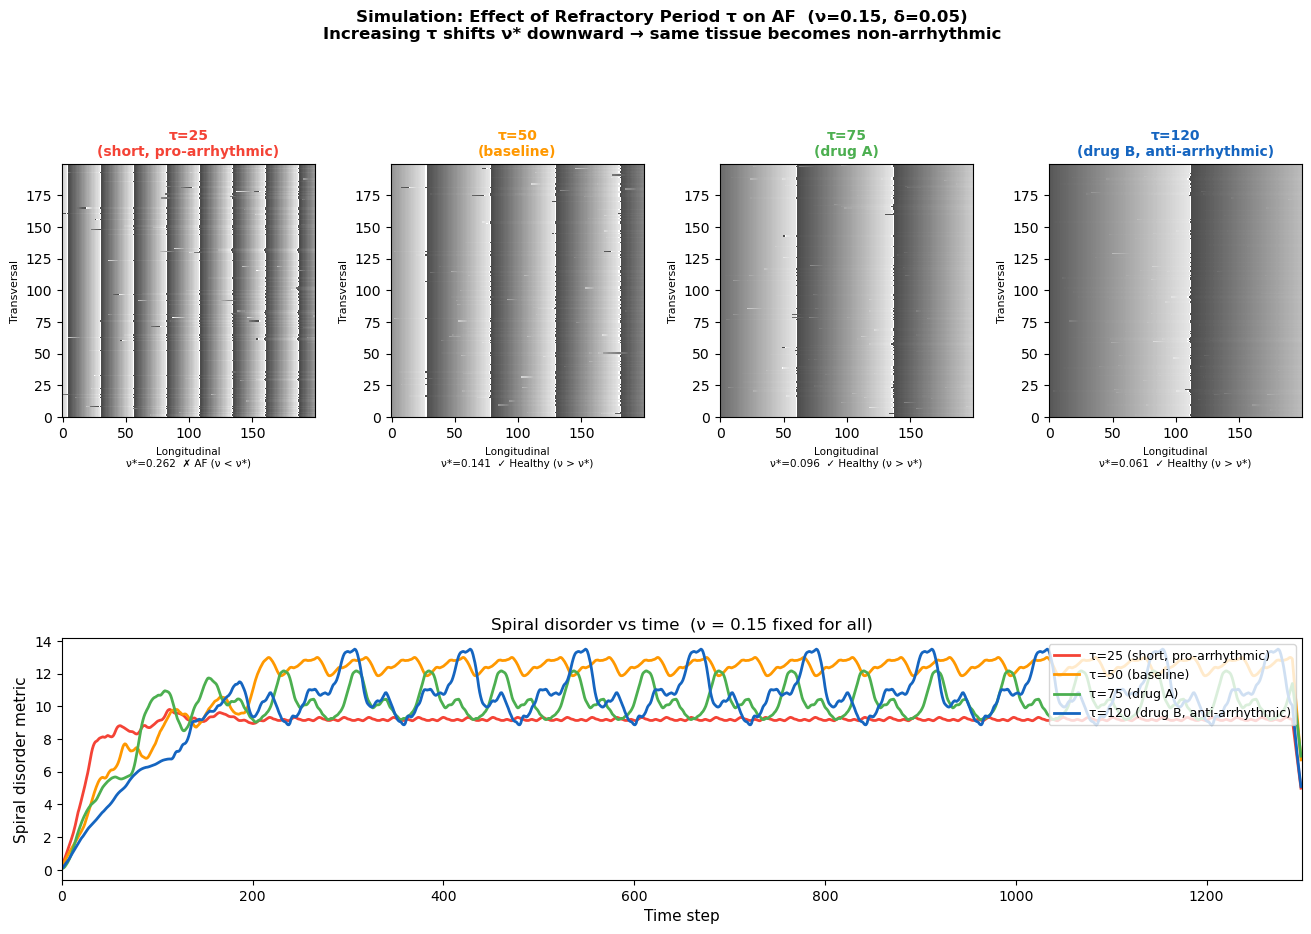


[3/3] Summary: disorder vs τ ...

  Computing summary (disorder vs τ at ν=0.15) ...
    τ= 20  →  mean disorder = 6.3
    τ= 30  →  mean disorder = 6.9
    τ= 40  →  mean disorder = 8.0
    τ= 50  →  mean disorder = 9.4
    τ= 60  →  mean disorder = 9.9
    τ= 75  →  mean disorder = 14.5
    τ= 90  →  mean disorder = 14.9
    τ=110  →  mean disorder = 10.0
    τ=130  →  mean disorder = 10.8


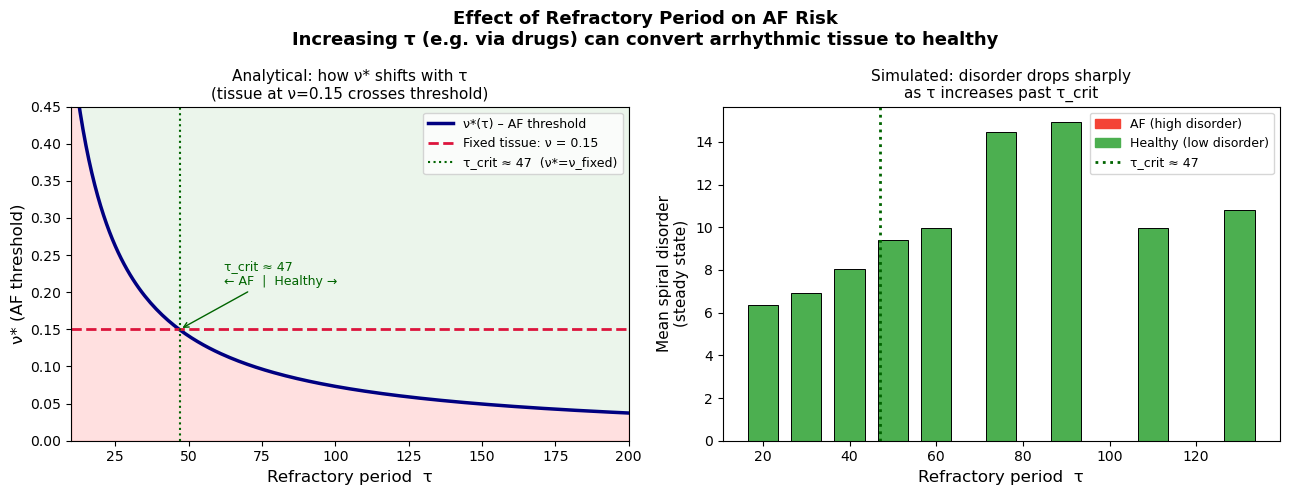

In [7]:
"""
Effect of Refractory Period (τ) on Spiral Formation & AF Risk
==============================================================
Question: "What will be the effect of increasing/decreasing
           the refractory period?"

Approach:
  1. Analytical: P_risk(ν) curves for different τ values
                 + threshold ν*(τ) as a function of τ
  2. Simulation: ABM snapshots & disorder metric for different τ
  3. Clinical connection: drugs that prolong τ lower P_risk

Based on: Christensen et al. PRL 114, 028104 (2015)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Parameters ───────────────────────────────
L      = 200
TAU    = 50      # baseline
T_PACE = 220
DELTA  = 0.05
EPS    = 0.05


# ══════════════════════════════════════════════
# 1.  ANALYTICAL SECTION
# ══════════════════════════════════════════════

def p_risk(nu, tau, delta=DELTA, L=L):
    """Eq.(2) Christensen 2015:  P_risk = 1 − [1−(1−ν)^τ]^(δL²)"""
    return 1.0 - (1.0 - (1.0 - nu) ** tau) ** (delta * L**2)


def nu_star(tau, delta=DELTA, L=L):
    """
    Threshold ν* = point of steepest slope of P_risk(ν).
    Analytically:  ν* ≈ 1 − (δL²)^(−1/τ)   [Christensen eq. after (2)]
    """
    return 1.0 - (delta * L**2) ** (-1.0 / tau)


def plot_analytical():
    nu_vals  = np.linspace(0, 1, 500)
    tau_list = [20, 35, 50, 75, 100, 150]
    colors   = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(tau_list)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: P_risk(ν) for each τ ───────────────
    ax = axes[0]
    for tau, col in zip(tau_list, colors):
        pr = p_risk(nu_vals, tau)
        ax.plot(nu_vals, pr, color=col, lw=2.2,
                label=f'τ = {tau}')
        ns = nu_star(tau)
        ax.axvline(ns, color=col, lw=0.8, ls='--', alpha=0.6)

    ax.set_xlabel('Fraction of transversal connections  ν', fontsize=12)
    ax.set_ylabel('Risk of AF  $P_{risk}$', fontsize=12)
    ax.set_title('$P_{risk}$ vs ν  for different refractory periods τ\n'
                 '(dashed verticals = threshold ν*)', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(0, 1); ax.set_ylim(-0.02, 1.05)

    # Shade "always AF" region for reference
    ax.fill_between(nu_vals[nu_vals < 0.05],
                    p_risk(nu_vals[nu_vals < 0.05], 50),
                    alpha=0.15, color='red')
    ax.text(0.02, 0.5, 'AF\nregion', color='red',
            fontsize=9, ha='center', va='center')

    # ── Right: ν*(τ) — how the threshold shifts ───
    ax2  = axes[1]
    taus = np.arange(10, 201, 1)
    ns_vals = nu_star(taus)

    ax2.plot(taus, ns_vals, 'navy', lw=2.5)
    ax2.fill_between(taus, 0, ns_vals, alpha=0.15, color='red',
                     label='AF zone  (ν < ν*)')
    ax2.fill_between(taus, ns_vals, 1, alpha=0.10, color='green',
                     label='Safe zone  (ν > ν*)')

    # Mark baseline τ=50 and two drug scenarios
    for tau_mark, label, col in [(50,  'Baseline\n(τ=50)',  'black'),
                                  (75,  'Drug A\n(τ=75)',   'blue'),
                                  (100, 'Drug B\n(τ=100)', 'darkgreen')]:
        ns_m = nu_star(tau_mark)
        ax2.plot(tau_mark, ns_m, 'o', color=col, ms=9, zorder=5)
        ax2.annotate(label, (tau_mark, ns_m),
                     textcoords='offset points', xytext=(8, 4),
                     fontsize=9, color=col)

    ax2.set_xlabel('Refractory period  τ  (time steps)', fontsize=12)
    ax2.set_ylabel('AF threshold  ν*', fontsize=12)
    ax2.set_title('AF threshold ν* decreases as τ increases\n'
                  'Longer τ → larger safe zone', fontsize=11)
    ax2.legend(fontsize=9, loc='upper right')
    ax2.set_xlim(10, 200); ax2.set_ylim(0, 0.5)

    fig.suptitle(
        'Analytical Effect of Refractory Period on AF Risk\n'
        r'$P_{risk} = 1 - [1-(1-\nu)^\tau]^{\delta L^2}$'
        f'   (δ={DELTA}, L={L})',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════
# 2.  SIMULATION SECTION
# ══════════════════════════════════════════════

def build_substrate(L, nu, delta, rng):
    transv    = rng.random((L, L)) < nu
    transv_up = transv
    transv_dn = np.roll(transv, -1, axis=0)
    dysfunc   = rng.random((L, L)) < delta
    return transv_up, transv_dn, dysfunc


def step(state, transv_up, transv_dn, dysfunc,
         tau_val, pacemaker_fire, rng, eps=EPS):
    new_state = np.zeros_like(state)

    refr_mask = state >= 2
    new_state[refr_mask] = state[refr_mask] - 1

    excit_mask = state == 1
    new_state[excit_mask] = tau_val + 1

    resting_mask = state == 0
    excit = state == 1

    excit_left  = np.roll(excit,  1, axis=1); excit_left[:, 0]   = False
    excit_right = np.roll(excit, -1, axis=1); excit_right[:, -1] = False
    excit_up = np.roll(excit,  1, axis=0) & transv_up
    excit_dn = np.roll(excit, -1, axis=0) & transv_dn

    has_excit_nbr = excit_left | excit_right | excit_up | excit_dn
    if pacemaker_fire:
        has_excit_nbr[:, 0] = True

    candidates    = resting_mask & has_excit_nbr
    fail          = rng.random((L, L)) < eps
    actually_fire = candidates & ~(dysfunc & fail)
    new_state[actually_fire] = 1
    return new_state


def disorder_metric(state):
    """Column-range of refractory levels → 0 for planar, high for spirals."""
    refr_rows, refr_cols = np.where(state >= 2)
    if len(refr_rows) == 0:
        return 0.0
    col_disorder = 0.0
    unique_cols  = np.unique(refr_cols)
    for c in unique_cols:
        vals = state[state[:, c] >= 2, c]
        if len(vals) > 1:
            col_disorder += (vals.max() - vals.min())
    return col_disorder / max(len(unique_cols), 1)


def run_sim(nu, tau_val, delta=DELTA, eps=EPS,
            n_steps=1200, snapshot_times=None, seed=42):
    rng = np.random.default_rng(seed)
    if snapshot_times is None:
        snapshot_times = set()

    transv_up, transv_dn, dysfunc = build_substrate(L, nu, delta, rng)
    state        = np.zeros((L, L), dtype=np.int32)
    t_since_pace = 0
    snapshots    = []
    metrics      = []

    for t in range(n_steps):
        pacemaker_fire = (t_since_pace == 0)
        state = step(state, transv_up, transv_dn, dysfunc,
                     tau_val, pacemaker_fire, rng, eps)
        t_since_pace = (t_since_pace + 1) % T_PACE

        if t in snapshot_times:
            snapshots.append((t, state.copy()))
        metrics.append(disorder_metric(state))

    return snapshots, metrics


def to_img(state, tau_val=TAU):
    img = np.zeros_like(state, dtype=float)
    img[state == 1] = 1.0
    refr = state >= 2
    if refr.any():
        img[refr] = 0.3 + 0.6 * (state[refr] - 2) / max(tau_val - 1, 1)
    return img


def plot_simulation():
    """
    Fix ν = 0.15 (just inside the AF zone for τ=50).
    Vary τ: 25 (short), 50 (baseline), 75, 120 (drug-prolonged).
    Show tissue snapshots + disorder metric over time.
    """
    tau_list = [25, 50, 75, 120]
    labels   = ['τ=25\n(short, pro-arrhythmic)',
                'τ=50\n(baseline)',
                'τ=75\n(drug A)',
                'τ=120\n(drug B, anti-arrhythmic)']
    colors   = ['#F44336', '#FF9800', '#4CAF50', '#1565C0']
    nu_fixed = 0.15          # in AF zone for small τ, safe zone for large τ
    n_steps  = 1300
    snap_t   = 1200

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 4, hspace=0.55, wspace=0.3,
                            height_ratios=[1.5, 1])

    all_metrics = []
    for col, (tau_v, label) in enumerate(zip(tau_list, labels)):
        print(f"  Simulating τ = {tau_v} ...")
        snaps, met = run_sim(nu=nu_fixed, tau_val=tau_v,
                             n_steps=n_steps,
                             snapshot_times={snap_t},
                             seed=7 + col)
        all_metrics.append(met)

        ax = fig.add_subplot(gs[0, col])
        if snaps:
            _, st = snaps[0]
            ax.imshow(to_img(st, tau_v),
                      cmap='gray', vmin=0, vmax=1,
                      origin='lower', interpolation='nearest')
        ax.set_title(label, fontsize=10, fontweight='bold',
                     color=colors[col])
        ax.set_xlabel('Longitudinal', fontsize=8)
        ax.set_ylabel('Transversal',  fontsize=8)

        # Overlay ν* for this τ
        ns = nu_star(tau_v)
        status = '✗ AF (ν < ν*)' if nu_fixed < ns else '✓ Healthy (ν > ν*)'
        ax.set_xlabel(f'Longitudinal\nν*={ns:.3f}  {status}', fontsize=7.5)

    # ── Disorder metric over time ──────────────────
    ax_m = fig.add_subplot(gs[1, :])
    window = 20
    for tau_v, met, color, label in zip(tau_list, all_metrics, colors, labels):
        smooth = np.convolve(met, np.ones(window)/window, mode='same')
        ax_m.plot(smooth, color=color, lw=2,
                  label=label.replace('\n', ' '))

    ax_m.set_xlabel('Time step', fontsize=11)
    ax_m.set_ylabel('Spiral disorder metric', fontsize=11)
    ax_m.set_title(f'Spiral disorder vs time  (ν = {nu_fixed} fixed for all)',
                   fontsize=12)
    ax_m.legend(fontsize=9, loc='upper right')
    ax_m.set_xlim(0, n_steps)

    fig.suptitle(
        f'Simulation: Effect of Refractory Period τ on AF  (ν={nu_fixed}, δ={DELTA})\n'
        'Increasing τ shifts ν* downward → same tissue becomes non-arrhythmic',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════
# 3.  SUMMARY: ν* vs τ  +  mean disorder vs τ
# ══════════════════════════════════════════════

def plot_summary():
    """
    Single figure connecting analytical ν*(τ) with
    simulated disorder at fixed ν=0.15.
    Highlights the 'therapeutic window'.
    """
    tau_sim_list = [20, 30, 40, 50, 60, 75, 90, 110, 130]
    nu_fixed     = 0.15
    n_steps      = 900
    mean_disorder = []

    print("\n  Computing summary (disorder vs τ at ν=0.15) ...")
    for tau_v in tau_sim_list:
        _, met = run_sim(nu=nu_fixed, tau_val=tau_v,
                         n_steps=n_steps, seed=200+tau_v)
        mean_disorder.append(np.mean(met[n_steps//2:]))
        print(f"    τ={tau_v:3d}  →  mean disorder = {mean_disorder[-1]:.1f}")

    # Analytical ν*(τ)
    taus_an = np.arange(10, 201)
    ns_an   = nu_star(taus_an)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: ν*(τ) with ν=0.15 marked ──────────
    ax = axes[0]
    ax.plot(taus_an, ns_an, 'navy', lw=2.5, label='ν*(τ) – AF threshold')
    ax.axhline(nu_fixed, color='crimson', lw=2, ls='--',
               label=f'Fixed tissue: ν = {nu_fixed}')
    ax.fill_between(taus_an, 0, ns_an, alpha=0.12, color='red')
    ax.fill_between(taus_an, ns_an, 0.5, alpha=0.08, color='green')

    # Find τ_crit where ν* = ν_fixed
    tau_crit = taus_an[np.argmin(np.abs(ns_an - nu_fixed))]
    ax.axvline(tau_crit, color='darkgreen', lw=1.5, ls=':',
               label=f'τ_crit ≈ {tau_crit}  (ν*=ν_fixed)')
    ax.annotate(f'τ_crit ≈ {tau_crit}\n← AF  |  Healthy →',
                xy=(tau_crit, nu_fixed),
                xytext=(tau_crit + 15, nu_fixed + 0.06),
                fontsize=9, color='darkgreen',
                arrowprops=dict(arrowstyle='->', color='darkgreen'))

    ax.set_xlabel('Refractory period  τ', fontsize=12)
    ax.set_ylabel('ν* (AF threshold)', fontsize=12)
    ax.set_title('Analytical: how ν* shifts with τ\n'
                 '(tissue at ν=0.15 crosses threshold)', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(10, 200); ax.set_ylim(0, 0.45)

    # ── Right: simulated disorder vs τ ───────────
    ax2 = axes[1]
    cols = ['#F44336' if d > 30 else '#4CAF50' for d in mean_disorder]
    bars = ax2.bar(tau_sim_list, mean_disorder, color=cols,
                   edgecolor='black', linewidth=0.7, width=7)
    ax2.axvline(tau_crit, color='darkgreen', lw=2, ls=':',
                label=f'τ_crit ≈ {tau_crit}')
    ax2.set_xlabel('Refractory period  τ', fontsize=12)
    ax2.set_ylabel('Mean spiral disorder\n(steady state)', fontsize=11)
    ax2.set_title('Simulated: disorder drops sharply\nas τ increases past τ_crit',
                  fontsize=11)
    ax2.legend(fontsize=9)

    # Color legend
    from matplotlib.patches import Patch
    ax2.legend(handles=[
        Patch(color='#F44336', label='AF (high disorder)'),
        Patch(color='#4CAF50', label='Healthy (low disorder)'),
        plt.Line2D([0],[0], color='darkgreen', ls=':', lw=2,
                   label=f'τ_crit ≈ {tau_crit}')
    ], fontsize=9)

    fig.suptitle(
        'Effect of Refractory Period on AF Risk\n'
        'Increasing τ (e.g. via drugs) can convert arrhythmic tissue to healthy',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── MAIN ─────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("Effect of Refractory Period τ on AF Risk")
    print("=" * 60)

    print("\n[1/3] Analytical curves ...")
    plot_analytical()

    print("\n[2/3] ABM simulations (ν=0.15 fixed, varying τ) ...")
    plot_simulation()

    print("\n[3/3] Summary: disorder vs τ ...")
    plot_summary()